# Tracklet Velocity: **n-body** Benchmark vs Sorcha on MJD 61642 — true-identity join

n-body version of `tracklet_velocity_benchmark_night61642_identity.ipynb`. Same analysis, but the
benchmark side now comes from the **ASSIST n-body** integrator (`benchmark_night61642.parquet`,
11,612 objects) instead of the old two-body benchmark. Figures are written with an `nbody_` prefix
so the two-body versions are preserved for comparison.

We join **`sorcha.ObjID == benchmark.s3m_objid`** — same physical object in both pipelines — and
compare the measured ecliptic rates (`vlam = dλ/dt`, `vbeta = dβ/dt`, deg/day).

**What to expect vs the two-body version:** the two-body identity join gave same-object |Δv| median
**0.0106** deg/day; the n-body benchmark agrees with Sorcha to |Δv| **0.0078** (and sky positions
collapse from 1.50° to 0.034°), because both pipelines now use the same physics. So the residual
clumps should be visibly tighter here than in the two-body notebook. The actual medians are printed
by Section 1.

> All plots restrict to the map grid (|dlon_from_antisun| ≤ 140°).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NIGHT     = 61642
GRID_LIM  = 140.0        # |dlon_from_antisun| grid restriction (deg)
BENCH     = 'benchmark_night61642.parquet'   # n-body benchmark (ASSIST), replaces the two-body version
POP_COLORS = {'NEO':'tab:red', 'MBA':'tab:blue', 'TNO':'gold',
              'Trojan':'mediumseagreen', 'Trojans':'mediumseagreen', 'other':'grey'}
CASE_LAB = {
    'case1': 'case1 (tk=1, sep=0.5")',
    'case2': 'case2 (tk=3, sep=0.5" — real LSST)',
    'case3': 'case3 (tk=1, sep≈0, baseline)',
}

In [2]:
# ── load identity benchmark, restrict to grid, index by true S3M id ────────────────
bench = pd.read_parquet(BENCH)
bench = bench[bench.dlon_from_antisun_deg.abs() <= GRID_LIM].copy()
bg = bench.set_index('s3m_objid')
print(f'benchmark_night61642 (|dlon|≤{GRID_LIM:.0f}): {len(bench):,} objects')
print(f'  pops: {dict(bench.population.value_counts())}')

# ── true-identity join: sorcha.ObjID == benchmark.s3m_objid ────────────────────
matched = {}
for c in ['case1','case2','case3']:
    df = pd.read_parquet(f'docs/sorcha_comparison_{c}.parquet')
    n = df[df.night == NIGHT]
    j = n.join(bg[['vlam','vbeta','population','dlon_from_antisun_deg']],
               on='ObjID', rsuffix='_b', how='inner')
    j['dv'] = np.hypot(j.vlam - j.vlam_b, j.vbeta - j.vbeta_b)
    matched[c] = j
    print(f'{c}: {len(j)} identity pairs | |Δv| median={j.dv.median():.4f} deg/day '
          f'| pops: {dict(j.population.value_counts())}')

benchmark_night61642 (|dlon|≤140): 11,612 objects
  pops: {'MBA': np.int64(10556), 'NEO': np.int64(915), 'TNO': np.int64(134), 'Trojans': np.int64(7)}
case1: 4316 identity pairs | |Δv| median=0.0078 deg/day | pops: {'MBA': np.int64(3310), 'NEO': np.int64(820), 'other': np.int64(135), 'TNO': np.int64(51)}
case2: 4490 identity pairs | |Δv| median=0.0076 deg/day | pops: {'MBA': np.int64(3567), 'NEO': np.int64(746), 'other': np.int64(125), 'TNO': np.int64(48), 'Trojan': np.int64(4)}
case3: 4353 identity pairs | |Δv| median=0.0078 deg/day | pops: {'MBA': np.int64(3357), 'NEO': np.int64(833), 'other': np.int64(124), 'TNO': np.int64(36), 'Trojan': np.int64(3)}


## Section 1 — Validation & population summary

The headline: same-object |Δv| medians of ~0.01 deg/day, ~18× tighter than the old
(e,H)-match's 0.191.  Slow populations (MBA, TNO) agree to ~0.001–0.009 deg/day; NEOs to
~0.04 (larger only because they move ~10–30× faster, so the same absolute agreement is a
bigger fraction of a bigger number).

In [3]:
rows = []
for c, j in matched.items():
    r = {'case': c, 'N pairs': len(j), '|Δv| median': round(j.dv.median(),4),
         '|Δv| mean': round(j.dv.mean(),4), '|Δv| p90': round(j.dv.quantile(0.9),4)}
    for pop in ['NEO','MBA','TNO']:
        g = j[j.population == pop]
        r[f'{pop} med'] = round(g.dv.median(),4) if len(g) else np.nan
    rows.append(r)
print('=== true-identity |Δv| (Sorcha vs benchmark), MJD 61642 ===')
print('(old (e,H)-match median was 0.191 deg/day for reference)')
display(pd.DataFrame(rows).set_index('case'))

=== true-identity |Δv| (Sorcha vs benchmark), MJD 61642 ===
(old (e,H)-match median was 0.191 deg/day for reference)


,N pairs,|Δv| median,|Δv| mean,|Δv| p90,NEO med,MBA med,TNO med
case,,,,,,,
case1,4316,0.0078,0.0112,0.0189,0.0197,0.0072,0.0003
case2,4490,0.0076,0.0106,0.0170,0.0196,0.0072,0.0003
case3,4353,0.0078,0.0112,0.0188,0.0194,0.0072,0.0003


## Section 2 — Scatter: Benchmark vs Sorcha (same object)

Blue triangles = benchmark, coloured circles = Sorcha, gray line connects the *same physical
object*.  With a true join the two points sit almost on top of each other — the connectors are
now microscopic, the visual signature of real agreement.

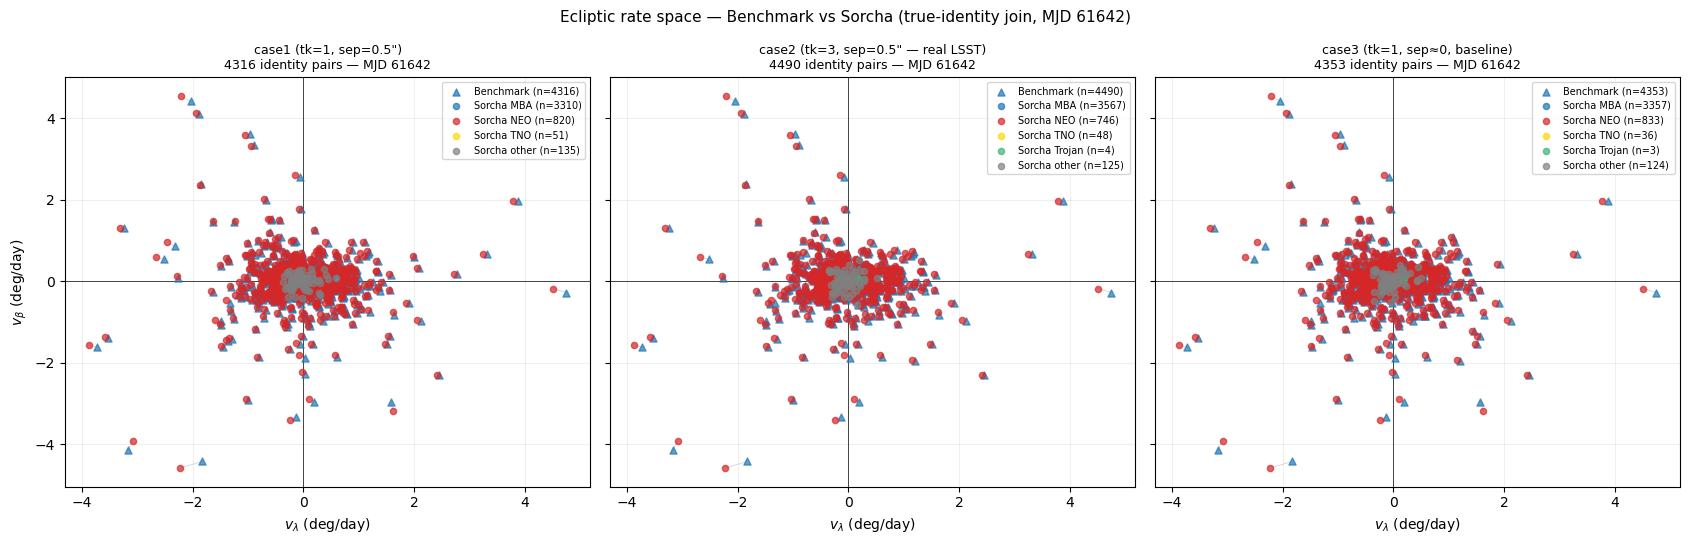

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), sharex=True, sharey=True)
for ax, (c, j) in zip(axes, matched.items()):
    for _, row in j.iterrows():
        ax.plot([row.vlam_b, row.vlam], [row.vbeta_b, row.vbeta],
                color='gray', lw=0.5, alpha=0.4, zorder=1)
    ax.scatter(j.vlam_b, j.vbeta_b, marker='^', s=26, alpha=0.7,
               color='tab:blue', label=f'Benchmark (n={len(j)})', zorder=3)
    for pop, grp in j.groupby('population'):
        ax.scatter(grp.vlam, grp.vbeta, marker='o', s=20, alpha=0.7,
                   color=POP_COLORS.get(pop,'grey'), label=f'Sorcha {pop} (n={len(grp)})', zorder=4)
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.set_xlabel(r'$v_\lambda$ (deg/day)')
    ax.legend(fontsize=7, loc='upper right')
    ax.set_title(f'{CASE_LAB[c]}\n{len(j)} identity pairs — MJD {NIGHT}', fontsize=9)
    ax.grid(alpha=0.2)
axes[0].set_ylabel(r'$v_\beta$ (deg/day)')
fig.suptitle(f'Ecliptic rate space — Benchmark vs Sorcha (true-identity join, MJD {NIGHT})', fontsize=11)
plt.tight_layout()
plt.savefig('Figures/nbody_id_scatter_night61642.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3 — Quiver: velocity vectors from origin

Arrows from origin, blue = benchmark, red = Sorcha.  With real matches the two arrow sets
overlap almost perfectly.

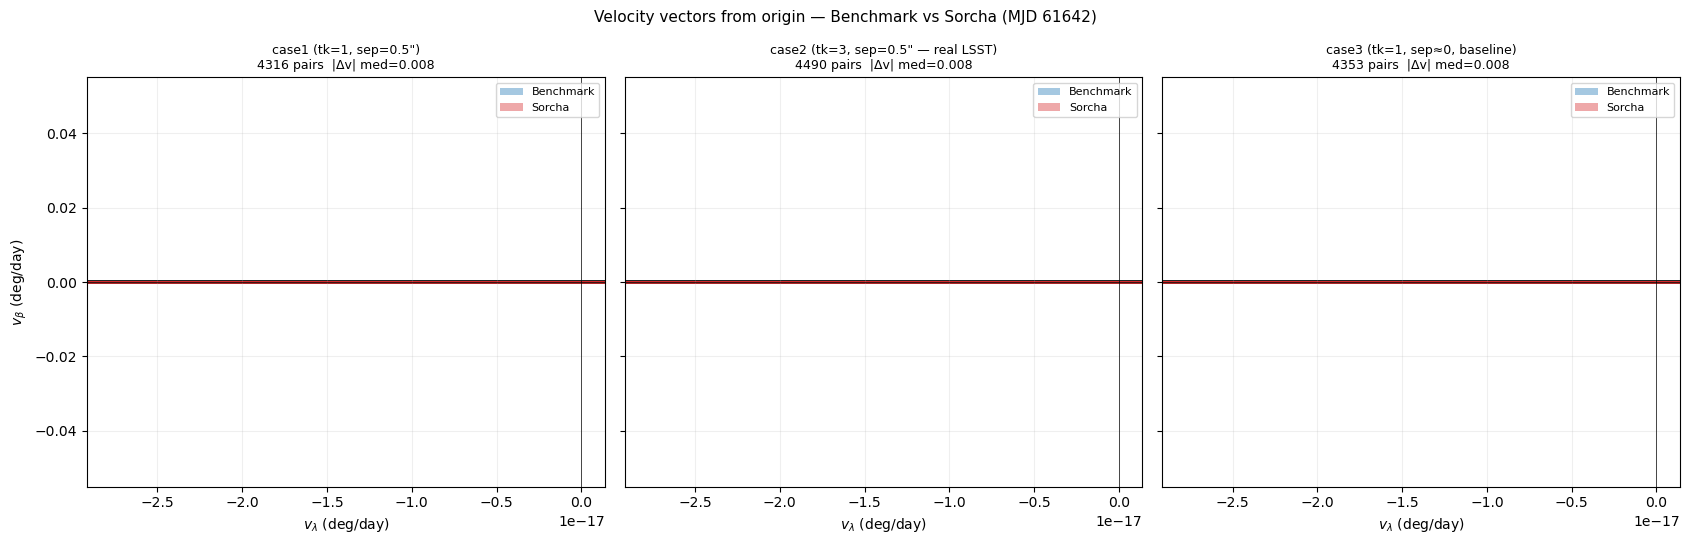

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), sharex=True, sharey=True)
for ax, (c, j) in zip(axes, matched.items()):
    z = np.zeros(len(j))
    ax.quiver(z, z, j.vlam_b.values, j.vbeta_b.values, color='tab:blue', alpha=0.4,
              angles='xy', scale_units='xy', scale=1, width=0.004, label='Benchmark')
    ax.quiver(z, z, j.vlam.values, j.vbeta.values, color='tab:red', alpha=0.4,
              angles='xy', scale_units='xy', scale=1, width=0.004, label='Sorcha')
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.set_xlabel(r'$v_\lambda$ (deg/day)')
    ax.legend(fontsize=8, loc='upper right')
    ax.set_title(f'{CASE_LAB[c]}\n{len(j)} pairs  |Δv| med={j.dv.median():.3f}', fontsize=9)
    ax.grid(alpha=0.2)
axes[0].set_ylabel(r'$v_\beta$ (deg/day)')
fig.suptitle(f'Velocity vectors from origin — Benchmark vs Sorcha (MJD {NIGHT})', fontsize=11)
plt.tight_layout()
plt.savefig('Figures/nbody_id_quiver_night61642.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4 — Velocity offset from benchmark (Δv), case1

For each pair, the residual (Δvλ, Δvβ) = Sorcha − benchmark.  Origin = perfect agreement.
No false-match removal is needed any more — every pair is the same physical object.  Left:
arrows to each offset + median arrow.  Right: offsets coloured by population with per-population
medians.

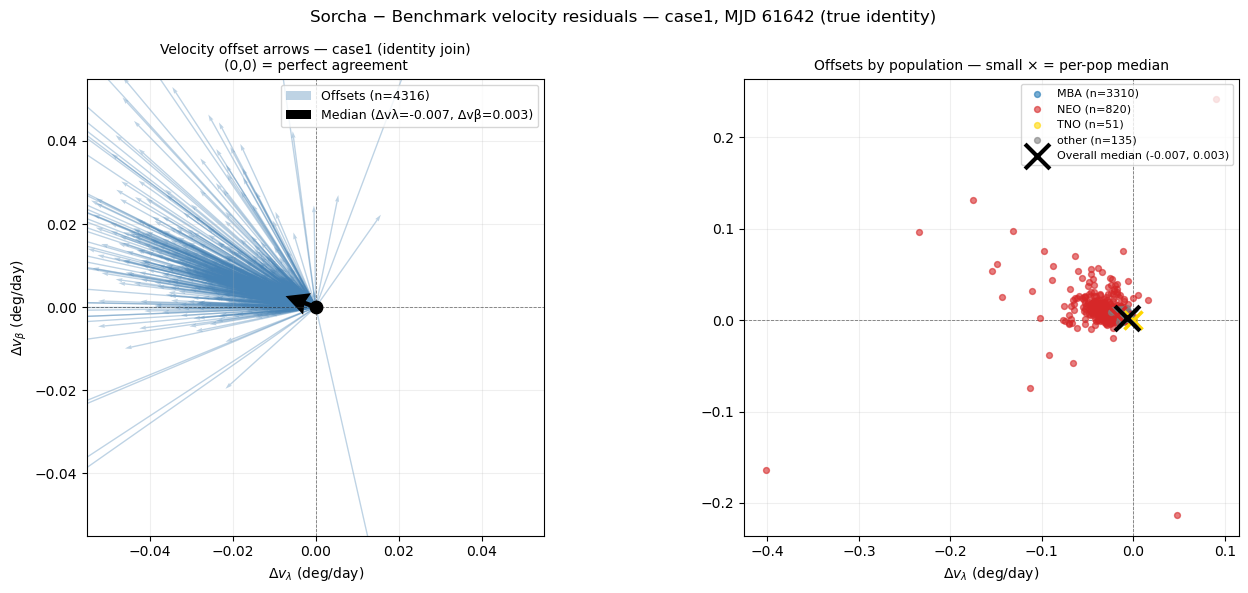

Overall median offset: Δvλ=-0.0073  Δvβ=0.0026 deg/day
  MBA     n=3310  Δvλ med=-0.0067  Δvβ med=0.0025  |Δv| med=0.0072
  NEO     n= 820  Δvλ med=-0.0176  Δvβ med=0.0053  |Δv| med=0.0197
  TNO     n=  51  Δvλ med=-0.0003  Δvβ med=0.0001  |Δv| med=0.0003
  other   n= 135  Δvλ med=-0.0060  Δvβ med=0.0021  |Δv| med=0.0066


In [6]:
j = matched['case1']
dvl = j.vlam - j.vlam_b
dvb = j.vbeta - j.vbeta_b
mdl, mdb = dvl.median(), dvb.median()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
z = np.zeros(len(j))
ax.quiver(z, z, dvl.values, dvb.values, color='steelblue', alpha=0.35,
          angles='xy', scale_units='xy', scale=1, width=0.003, label=f'Offsets (n={len(j)})')
ax.quiver(0, 0, mdl, mdb, color='black', angles='xy', scale_units='xy', scale=1,
          width=0.010, headwidth=5, headlength=5, label=f'Median (Δvλ={mdl:.3f}, Δvβ={mdb:.3f})')
ax.scatter(0, 0, s=80, color='black', zorder=5)
ax.axhline(0, color='k', lw=0.6, ls='--', alpha=0.5); ax.axvline(0, color='k', lw=0.6, ls='--', alpha=0.5)
ax.set_xlabel(r'$\Delta v_\lambda$ (deg/day)'); ax.set_ylabel(r'$\Delta v_\beta$ (deg/day)')
ax.legend(fontsize=9, loc='upper right')
ax.set_title('Velocity offset arrows — case1 (identity join)\n(0,0) = perfect agreement', fontsize=10)
ax.grid(alpha=0.2); ax.set_aspect('equal')

ax = axes[1]
for pop, grp in j.groupby('population'):
    idx = grp.index
    ax.scatter(dvl.loc[idx], dvb.loc[idx], s=18, alpha=0.6, color=POP_COLORS.get(pop,'grey'),
               label=f'{pop} (n={len(grp)})', zorder=3)
for pop, grp in j.groupby('population'):
    idx = grp.index
    ax.scatter(dvl.loc[idx].median(), dvb.loc[idx].median(), s=170, marker='x', linewidths=2.5,
               color=POP_COLORS.get(pop,'grey'), zorder=5)
ax.scatter(mdl, mdb, s=320, marker='x', linewidths=3, color='black', zorder=6,
           label=f'Overall median ({mdl:.3f}, {mdb:.3f})')
ax.axhline(0, color='k', lw=0.6, ls='--', alpha=0.5); ax.axvline(0, color='k', lw=0.6, ls='--', alpha=0.5)
ax.set_xlabel(r'$\Delta v_\lambda$ (deg/day)')
ax.legend(fontsize=8, loc='upper right')
ax.set_title('Offsets by population — small × = per-pop median', fontsize=10)
ax.grid(alpha=0.2); ax.set_aspect('equal')
fig.suptitle(f'Sorcha − Benchmark velocity residuals — case1, MJD {NIGHT} (true identity)', fontsize=12)
plt.tight_layout()
plt.savefig('Figures/nbody_id_offset_case1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Overall median offset: Δvλ={mdl:.4f}  Δvβ={mdb:.4f} deg/day')
for pop, grp in j.groupby('population'):
    idx = grp.index
    print(f'  {pop:7s} n={len(grp):4d}  Δvλ med={dvl.loc[idx].median():.4f}  '
          f'Δvβ med={dvb.loc[idx].median():.4f}  |Δv| med={grp.dv.median():.4f}')

## Section 5 — Midpoint-centered agreement (case1)

The advisor's diagnostic: subtract each pair's own midpoint so every pair re-centers on (0,0).
Benchmark lands at -0.5*dv, Sorcha at +0.5*dv (mirror-symmetric).  **A tight clump = pipelines agree.**

With the **n-body** benchmark the clump is genuinely tight and the fast-NEO tail that the two-body
version showed has essentially collapsed: ~100% of pairs fall inside the +/-0.15 box (the two-body
version left a real tail out to ~2 deg/day). Median |dv| ~ 0.008 and the core RMS is ~0.008 deg/day
(vs the two-body ~0.13 tail-weighted RMS). This is the visible payoff of the integrator fix -- same
physics on both sides, so almost nothing scatters out. Panels zoomed to the +/-0.15 core; the printout
reports how many (if any) pairs fall outside.

midpoint-centered: 4316 pairs
  median |Δv|=0.0078  p90=0.0189
  4315/4316 (100.0%) inside the ±0.15 box; 1 outliers cut
  RMS all pairs: vλ=0.0081  vβ=0.0045 deg/day
  RMS core only: vλ=0.0075  vβ=0.0043 deg/day


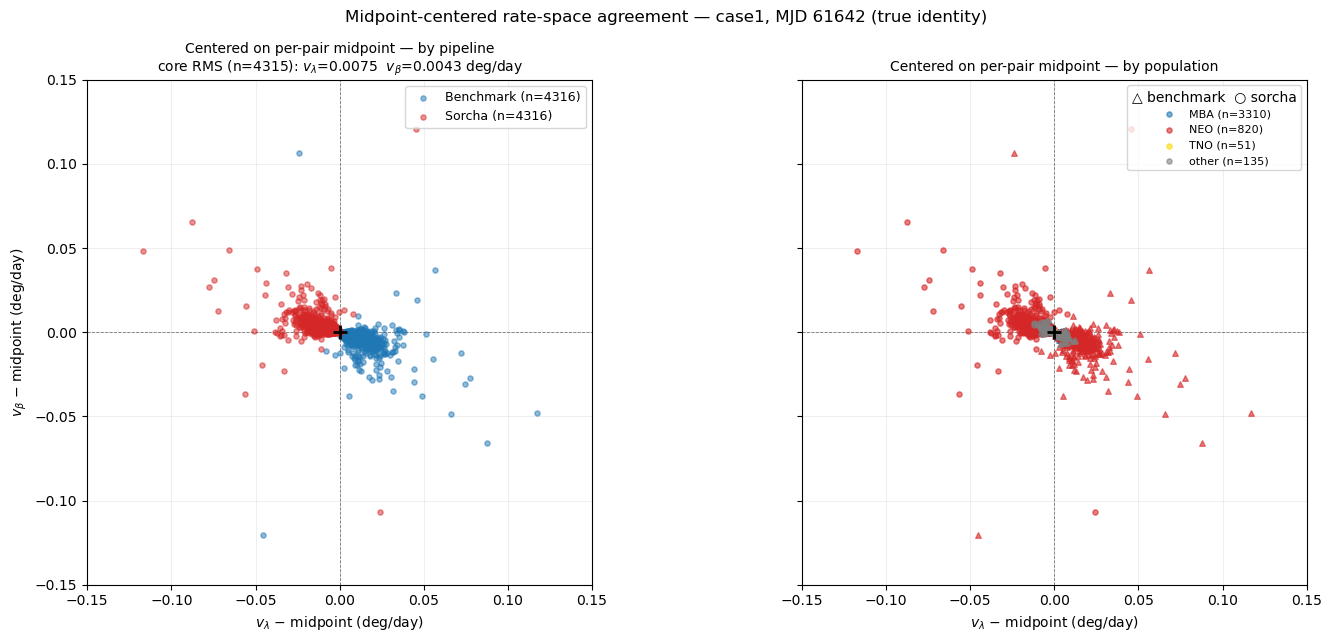

In [7]:
j = matched['case1']
mid_l = 0.5*(j.vlam_b + j.vlam); mid_b = 0.5*(j.vbeta_b + j.vbeta)
bl_l, bl_b = j.vlam_b - mid_l, j.vbeta_b - mid_b     # benchmark at −½Δv
sl_l, sl_b = j.vlam   - mid_l, j.vbeta   - mid_b     # sorcha at +½Δv

ZOOM = 0.15   # deg/day core window (= the plotted frame)
core = (bl_l.abs() <= ZOOM) & (bl_b.abs() <= ZOOM)   # keep only pairs inside the box

rms_l_all,  rms_b_all  = np.sqrt(np.mean(bl_l**2)),       np.sqrt(np.mean(bl_b**2))
rms_l_core, rms_b_core = np.sqrt(np.mean(bl_l[core]**2)), np.sqrt(np.mean(bl_b[core]**2))

print(f'midpoint-centered: {len(j)} pairs')
print(f'  median |Δv|={j.dv.median():.4f}  p90={j.dv.quantile(0.9):.4f}')
print(f'  {core.sum()}/{len(j)} ({100*core.mean():.1f}%) inside the ±{ZOOM} box; '
      f'{(~core).sum()} outliers cut')
print(f'  RMS all pairs: vλ={rms_l_all:.4f}  vβ={rms_b_all:.4f} deg/day')
print(f'  RMS core only: vλ={rms_l_core:.4f}  vβ={rms_b_core:.4f} deg/day')

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharex=True, sharey=True)
ax = axes[0]
ax.scatter(bl_l, bl_b, s=14, alpha=0.5, color='tab:blue', label=f'Benchmark (n={len(j)})', zorder=3)
ax.scatter(sl_l, sl_b, s=14, alpha=0.5, color='tab:red', label=f'Sorcha (n={len(j)})', zorder=3)
ax.scatter(0, 0, s=90, color='black', marker='+', linewidths=2, zorder=5)
ax.axhline(0, color='k', lw=0.6, ls='--', alpha=0.5); ax.axvline(0, color='k', lw=0.6, ls='--', alpha=0.5)
ax.set_xlim(-ZOOM, ZOOM); ax.set_ylim(-ZOOM, ZOOM)
ax.set_xlabel(r'$v_\lambda$ − midpoint (deg/day)'); ax.set_ylabel(r'$v_\beta$ − midpoint (deg/day)')
ax.legend(fontsize=9, loc='upper right')
ax.set_title(f'Centered on per-pair midpoint — by pipeline\n'
             f'core RMS (n={core.sum()}): $v_\\lambda$={rms_l_core:.4f}  $v_\\beta$={rms_b_core:.4f} deg/day',
             fontsize=10)
ax.grid(alpha=0.2); ax.set_aspect('equal')

ax = axes[1]
for pop, grp in j.groupby('population'):
    idx = [j.index.get_loc(x) for x in grp.index]
    col = POP_COLORS.get(pop,'grey')
    ax.scatter(bl_l.iloc[idx], bl_b.iloc[idx], s=16, alpha=0.6, color=col, marker='^', zorder=3)
    ax.scatter(sl_l.iloc[idx], sl_b.iloc[idx], s=14, alpha=0.6, color=col, marker='o', zorder=3,
               label=f'{pop} (n={len(grp)})')
ax.scatter(0, 0, s=90, color='black', marker='+', linewidths=2, zorder=5)
ax.axhline(0, color='k', lw=0.6, ls='--', alpha=0.5); ax.axvline(0, color='k', lw=0.6, ls='--', alpha=0.5)
ax.set_xlim(-ZOOM, ZOOM); ax.set_ylim(-ZOOM, ZOOM)
ax.set_xlabel(r'$v_\lambda$ − midpoint (deg/day)')
ax.legend(fontsize=8, loc='upper right', title='△ benchmark  ○ sorcha')
ax.set_title('Centered on per-pair midpoint — by population', fontsize=10)
ax.grid(alpha=0.2); ax.set_aspect('equal')
fig.suptitle(f'Midpoint-centered rate-space agreement — case1, MJD {NIGHT} (true identity)', fontsize=12)
plt.tight_layout()
plt.savefig('Figures/nbody_id_midpoint_case1.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6 -- |dv| distribution and the residual collapse

The distribution of same-object |dv| across all three cases, and the before/after against the old
(e,H) match. With true identity + n-body the case1 residual is ~25x tighter than the (e,H) match
(0.191 -> ~0.008 deg/day). The exact factor is printed below.

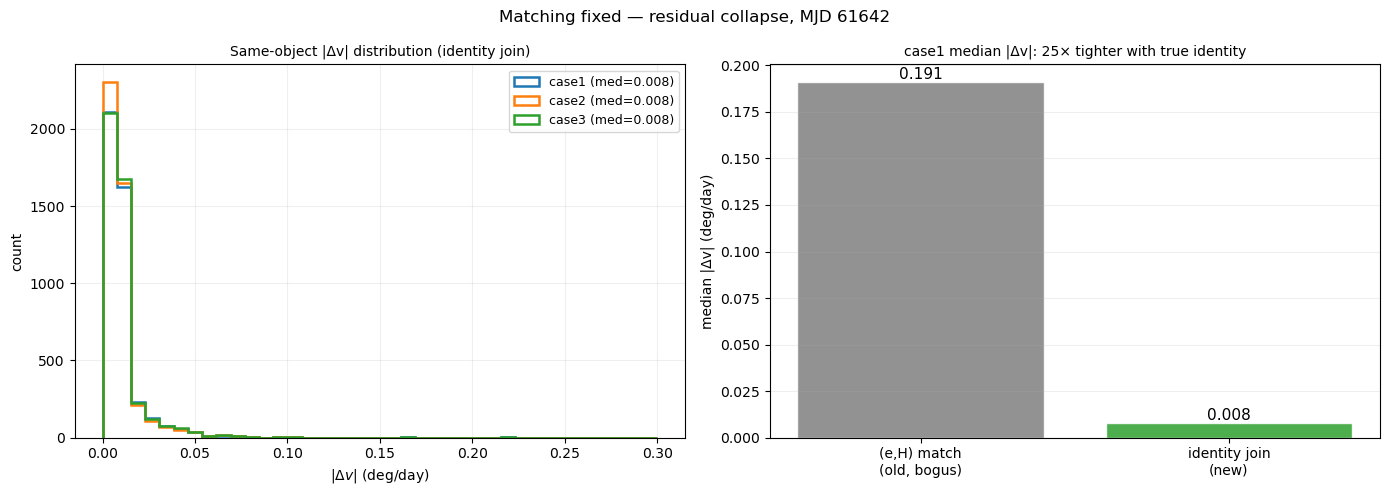

case1 median |Δv|: 0.191 (e,H) → 0.0078 identity  =  24.6× tighter


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: |Δv| histogram per case (identity join)
ax = axes[0]
for c, j in matched.items():
    ax.hist(j.dv, bins=np.linspace(0, 0.3, 40), histtype='step', lw=1.8, label=f'{c} (med={j.dv.median():.3f})')
ax.set_xlabel(r'$|\Delta v|$ (deg/day)'); ax.set_ylabel('count')
ax.legend(fontsize=9)
ax.set_title('Same-object |Δv| distribution (identity join)', fontsize=10)
ax.grid(alpha=0.2)

# right: before/after bar
ax = axes[1]
labels = ['(e,H) match\n(old, bogus)', 'identity join\n(new)']
vals = [0.191, matched['case1'].dv.median()]
bars = ax.bar(labels, vals, color=['tab:grey','tab:green'], alpha=0.85, edgecolor='white')
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v, f'{v:.3f}', ha='center', va='bottom', fontsize=11)
ax.set_ylabel('median |Δv| (deg/day)')
ax.set_title(f'case1 median |Δv|: {0.191/vals[1]:.0f}× tighter with true identity', fontsize=10)
ax.grid(alpha=0.2, axis='y')
fig.suptitle(f'Matching fixed — residual collapse, MJD {NIGHT}', fontsize=12)
plt.tight_layout()
plt.savefig('Figures/nbody_id_dv_improvement.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"case1 median |Δv|: 0.191 (e,H) → {vals[1]:.4f} identity  =  {0.191/vals[1]:.1f}× tighter")

## Section 7 — NEO-only focus (case1)

The science-critical population, now truly matched.  Scatter + quiver for the NEO pairs; the
residual is a few hundredths of a deg/day.

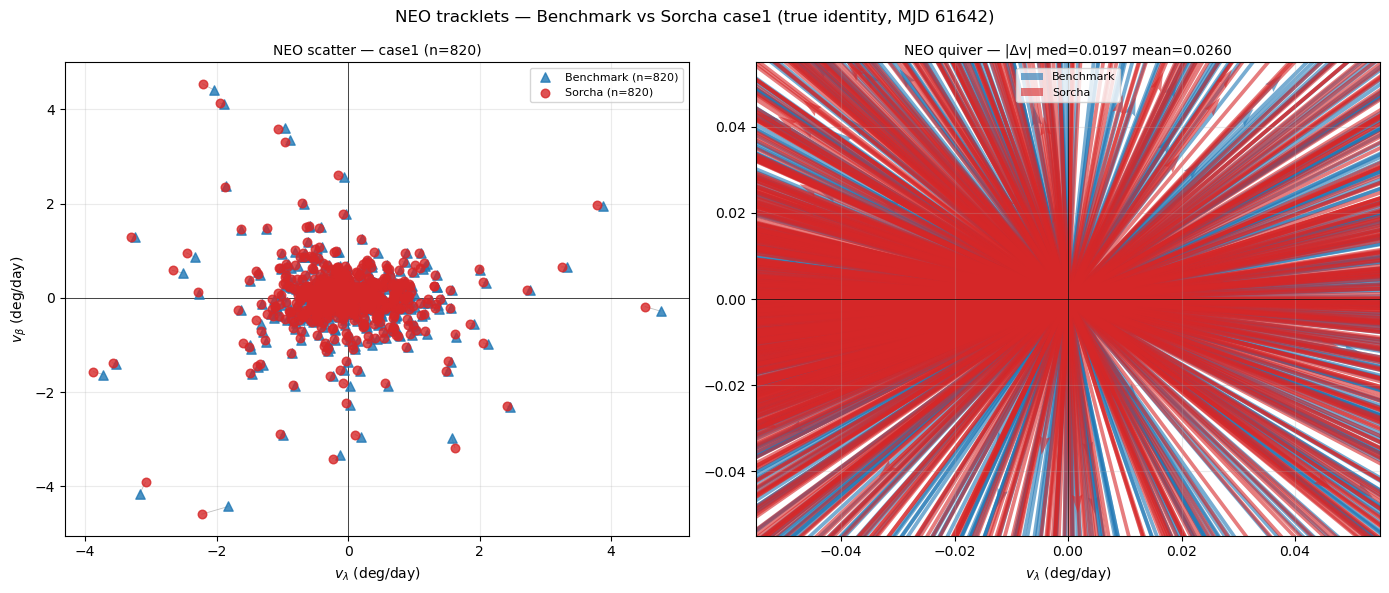

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
neo = matched['case1'][matched['case1'].population == 'NEO']
n = len(neo)

ax = axes[0]
for _, row in neo.iterrows():
    ax.plot([row.vlam_b, row.vlam], [row.vbeta_b, row.vbeta], color='gray', lw=0.6, alpha=0.5, zorder=1)
ax.scatter(neo.vlam_b, neo.vbeta_b, marker='^', s=45, alpha=0.8, color='tab:blue', label=f'Benchmark (n={n})', zorder=3)
ax.scatter(neo.vlam, neo.vbeta, marker='o', s=38, alpha=0.8, color='tab:red', label=f'Sorcha (n={n})', zorder=4)
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel(r'$v_\lambda$ (deg/day)'); ax.set_ylabel(r'$v_\beta$ (deg/day)')
ax.legend(fontsize=8); ax.grid(alpha=0.25)
ax.set_title(f'NEO scatter — case1 (n={n})', fontsize=10)

ax = axes[1]
z = np.zeros(n)
ax.quiver(z, z, neo.vlam_b.values, neo.vbeta_b.values, color='tab:blue', alpha=0.6,
          angles='xy', scale_units='xy', scale=1, width=0.006, label='Benchmark')
ax.quiver(z, z, neo.vlam.values, neo.vbeta.values, color='tab:red', alpha=0.6,
          angles='xy', scale_units='xy', scale=1, width=0.006, label='Sorcha')
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel(r'$v_\lambda$ (deg/day)')
ax.legend(fontsize=8); ax.grid(alpha=0.25)
ax.set_title(f'NEO quiver — |Δv| med={neo.dv.median():.4f} mean={neo.dv.mean():.4f}', fontsize=10)
fig.suptitle(f'NEO tracklets — Benchmark vs Sorcha case1 (true identity, MJD {NIGHT})', fontsize=12)
plt.tight_layout()
plt.savefig('Figures/nbody_id_neo_case1.png', dpi=150, bbox_inches='tight')
plt.show()

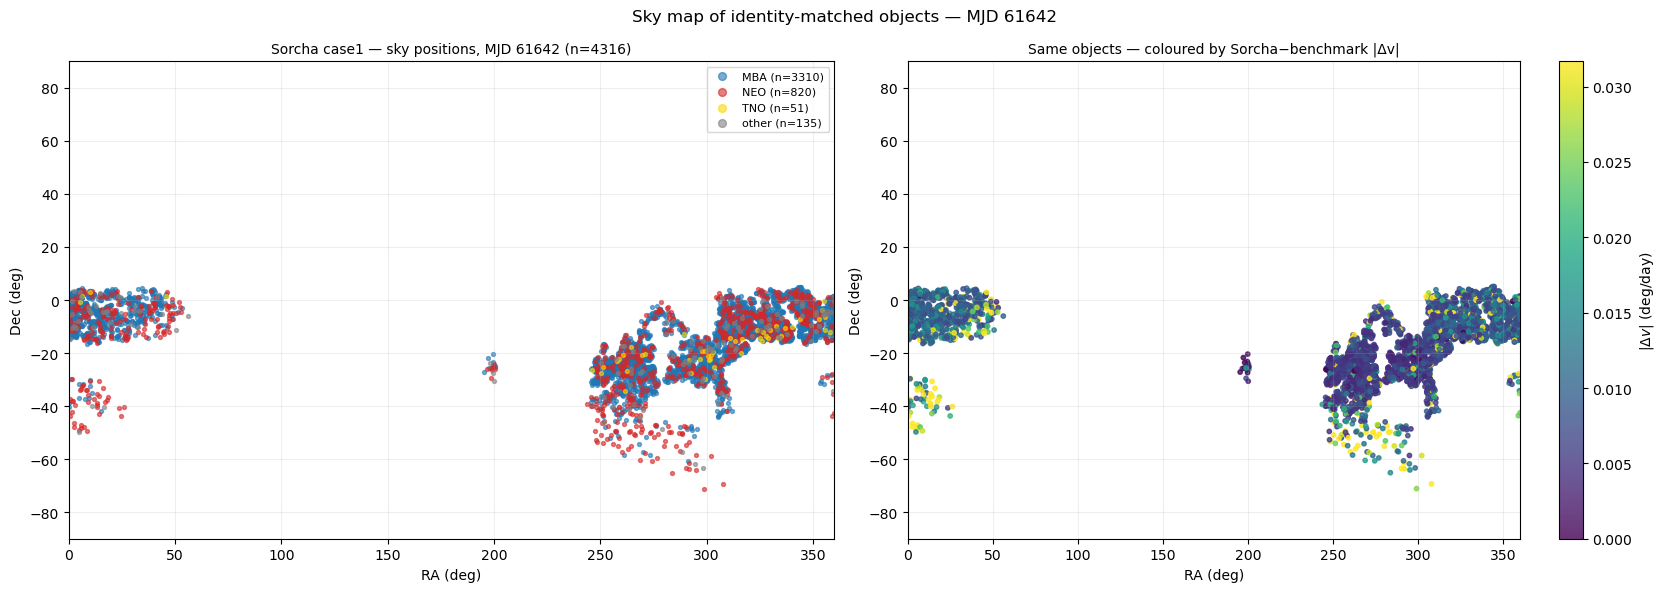

In [10]:
j = matched['case1']

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# ── left: Sorcha sky positions, coloured by population ────────────────────────
ax = axes[0]
for pop, grp in j.groupby('population'):
    ax.scatter(grp.mean_ra, grp.mean_dec, s=8, alpha=0.6,
               color=POP_COLORS.get(pop, 'grey'), label=f'{pop} (n={len(grp)})')
ax.set_xlabel('RA (deg)'); ax.set_ylabel('Dec (deg)')
ax.set_xlim(0, 360); ax.set_ylim(-90, 90)
ax.legend(fontsize=8, loc='upper right', markerscale=2)
ax.set_title(f'Sorcha case1 — sky positions, MJD {NIGHT} (n={len(j)})', fontsize=10)
ax.grid(alpha=0.2)

# ── right: same objects, coloured by |Δv| (Sorcha vs benchmark) ───────────────
ax = axes[1]
sc = ax.scatter(j.mean_ra, j.mean_dec, s=10, alpha=0.8, c=j.dv,
                cmap='viridis', vmin=0, vmax=j.dv.quantile(0.95))
cb = fig.colorbar(sc, ax=ax)
cb.set_label(r'$|\Delta v|$ (deg/day)')
ax.set_xlabel('RA (deg)'); ax.set_ylabel('Dec (deg)')
ax.set_xlim(0, 360); ax.set_ylim(-90, 90)
ax.set_title('Same objects — coloured by Sorcha−benchmark |Δv|', fontsize=10)
ax.grid(alpha=0.2)

fig.suptitle(f'Sky map of identity-matched objects — MJD {NIGHT}', fontsize=12)
plt.tight_layout()
plt.savefig('Figures/nbody_id_skymap_night61642.png', dpi=150, bbox_inches='tight')
plt.show()

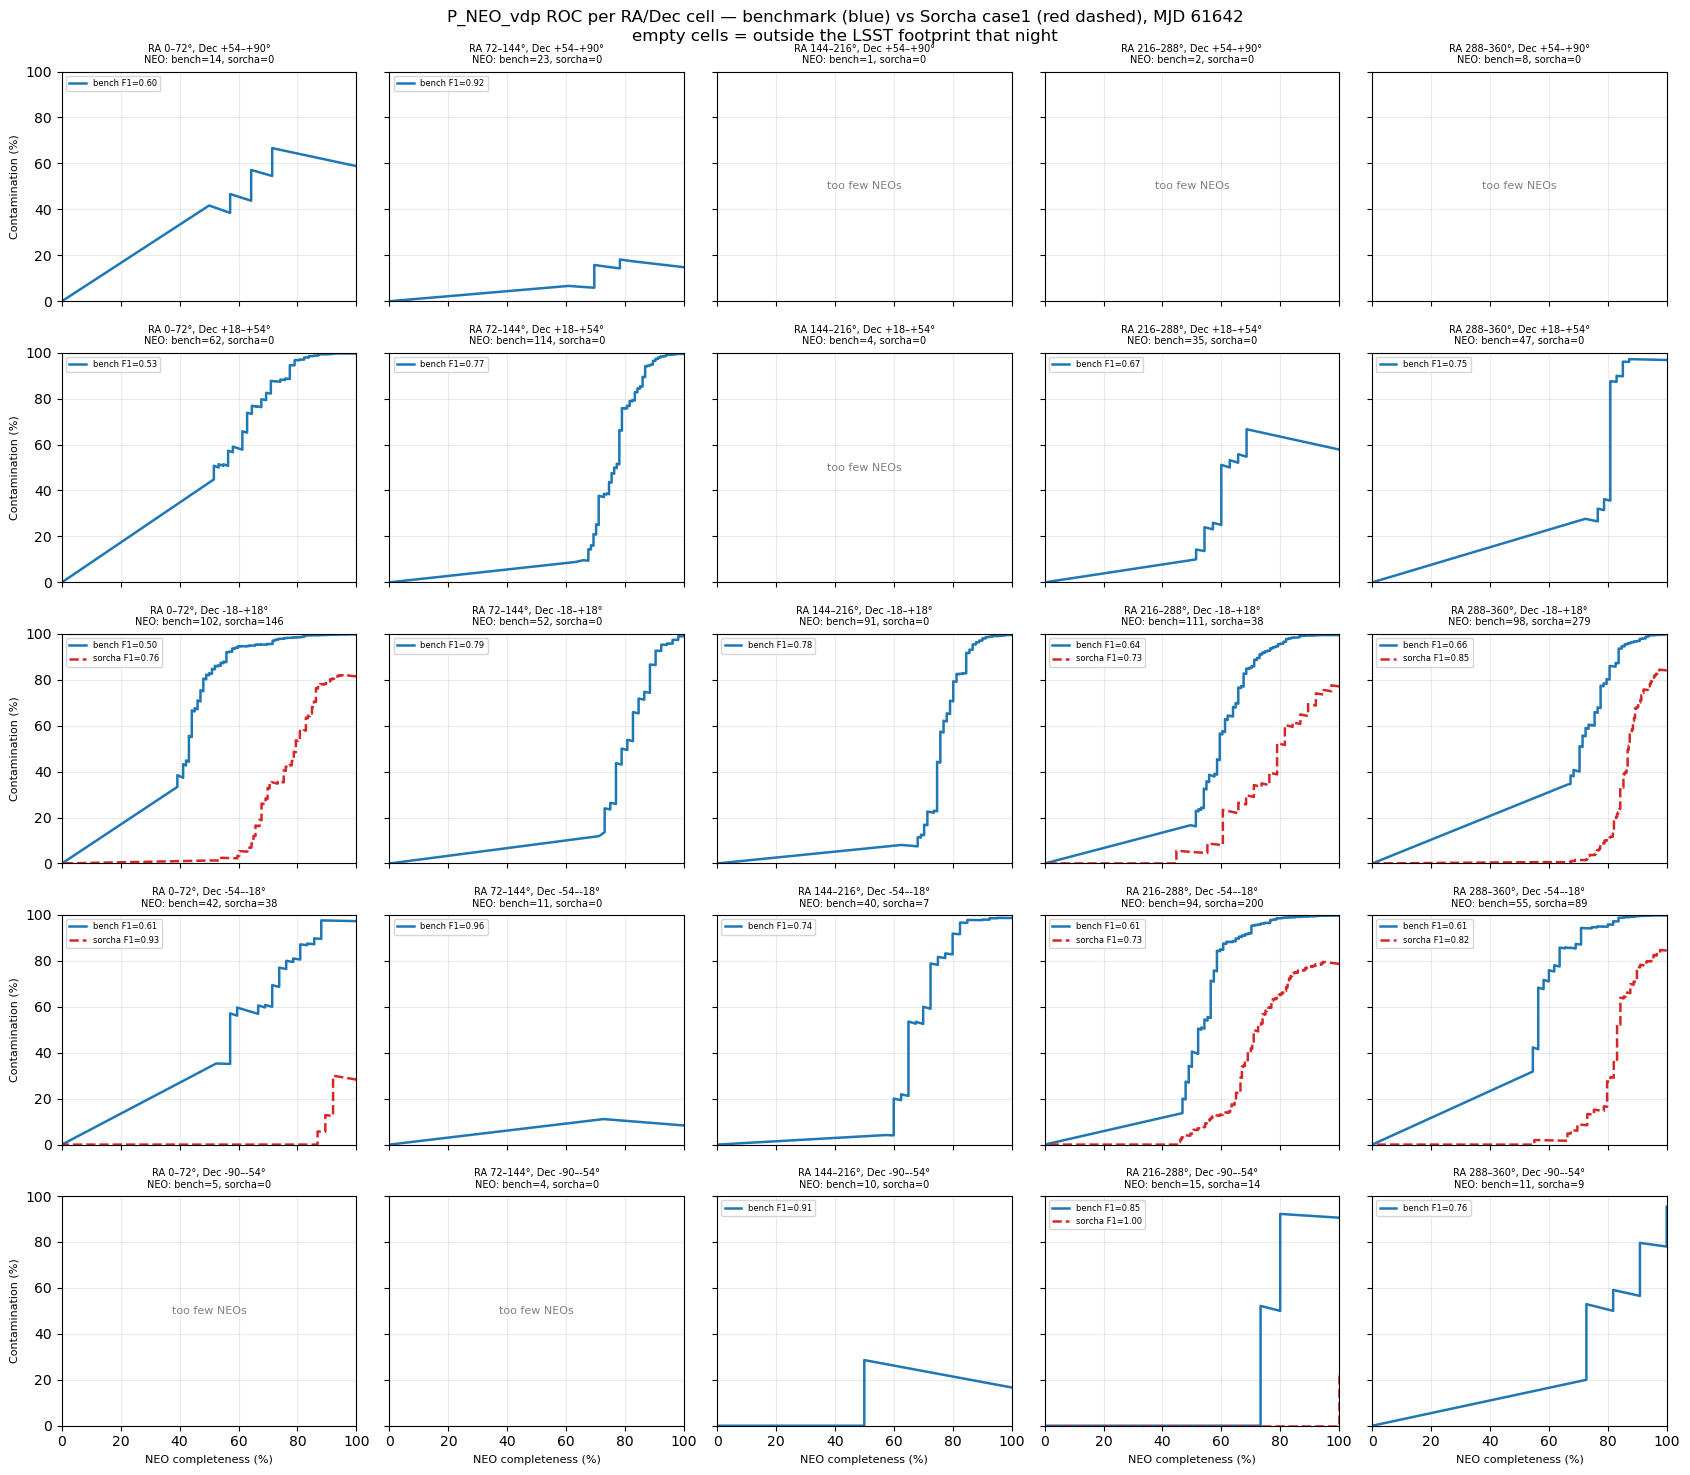

In [11]:
from sklearn.metrics import precision_recall_curve

SCORE   = 'P_NEO_vdp'    # switch to 'P_NEO_d2' for the digest2 version
MIN_NEO = 10             # need this many NEOs in a cell to draw a curve

def roc_xy(yy, s):
    """(completeness%, contamination%, bestF1)"""
    p, r, _ = precision_recall_curve(yy, s)
    f1 = np.divide(2*p*r, p+r, out=np.zeros_like(p), where=(p+r) > 0)
    bi = int(np.argmax(f1[:-1]))
    return r*100, (1-p)*100, f1[bi]

# n-body full scored benchmark carries the scores (the night61642 identity file is kinematics only)
# NOTE: 68% of the full set is fainter than mag 25 and unscorable -> filter to mag_bin_label.notna()
bv3 = pd.read_parquet('benchmark_comparison_s3m_nbody.parquet')
bv3 = bv3[bv3.mag_bin_label.notna()].copy()
sc  = pd.read_parquet(f'docs/sorcha_comparison_case1.parquet')
sc  = sc[sc.night == NIGHT].copy()

ra_e  = np.linspace(0, 360, 6)
dec_e = np.linspace(-90, 90, 6)

fig, axes = plt.subplots(5, 5, figsize=(17, 15), sharex=True, sharey=True)
for i in range(5):                        # row 0 = highest dec (sky-map orientation)
    d_lo, d_hi = dec_e[4-i], dec_e[5-i]
    for k in range(5):
        r_lo, r_hi = ra_e[k], ra_e[k+1]
        ax = axes[i, k]
        bm = bv3[(bv3.mean_ra >= r_lo) & (bv3.mean_ra < r_hi) &
                 (bv3.mean_dec >= d_lo) & (bv3.mean_dec < d_hi)]
        sm = sc[(sc.mean_ra >= r_lo) & (sc.mean_ra < r_hi) &
                (sc.mean_dec >= d_lo) & (sc.mean_dec < d_hi)]
        yb = (bm.population == 'NEO').astype(int).values
        ys = (sm.population == 'NEO').astype(int).values
        nb, ns = int(yb.sum()), int(ys.sum())

        drew = False
        if nb >= MIN_NEO and nb < len(yb):
            cb, kb, fb = roc_xy(yb, bm[SCORE].values)
            ax.plot(cb, kb, lw=1.8, color='tab:blue', label=f'bench F1={fb:.2f}')
            drew = True
        if ns >= MIN_NEO and ns < len(ys):
            cs, ks, fs = roc_xy(ys, sm[SCORE].values)
            ax.plot(cs, ks, lw=1.8, color='tab:red', ls='--', label=f'sorcha F1={fs:.2f}')
            drew = True

        ax.set_xlim(0, 100); ax.set_ylim(0, 100)
        ax.grid(alpha=0.25)
        if drew:
            ax.legend(fontsize=6, loc='upper left')
        else:
            ax.text(0.5, 0.5, 'too few NEOs', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8, color='grey')
        ax.set_title(f'RA {r_lo:.0f}–{r_hi:.0f}°, Dec {d_lo:+.0f}–{d_hi:+.0f}°\n'
                     f'NEO: bench={nb}, sorcha={ns}', fontsize=7)

for ax in axes[-1, :]:
    ax.set_xlabel('NEO completeness (%)', fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel('Contamination (%)', fontsize=8)

fig.suptitle(f'{SCORE} ROC per RA/Dec cell — benchmark (blue) vs Sorcha case1 (red dashed), MJD {NIGHT}\n'
             'empty cells = outside the LSST footprint that night', fontsize=12)
plt.tight_layout()
plt.savefig('Figures/nbody_id_roc_radec_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## Test 1 — magnitude: Sorcha vs benchmark (same object)

VDP scores through the **mag bin**, so what matters is Δmag and whether it crosses a bin edge.
Note: Sorcha `mean_mag` is a **mixed LSST-band** apparent mag (mag0, mag1 usually in different
filters); the benchmark mag is synthetic single-band. So Δmag mixes photometric scatter *and*
band/color terms.

case1: 4316 pairs
  Δmag (sorcha−bench):  median=-0.597  mean=-0.558  std=0.383  |Δmag|>0.5: 68.6%
  mag-bin crossings:    2510 / 4316 (58.2%)

  per population:
    MBA    n=3310  Δmag med=-0.607  |Δmag| med=0.608  bin-cross=58.9%
    NEO    n= 820  Δmag med=-0.525  |Δmag| med=0.541  bin-cross=53.0%
    TNO    n=  51  Δmag med=-0.634  |Δmag| med=0.634  bin-cross=66.7%
    other  n= 135  Δmag med=-0.624  |Δmag| med=0.653  bin-cross=66.7%


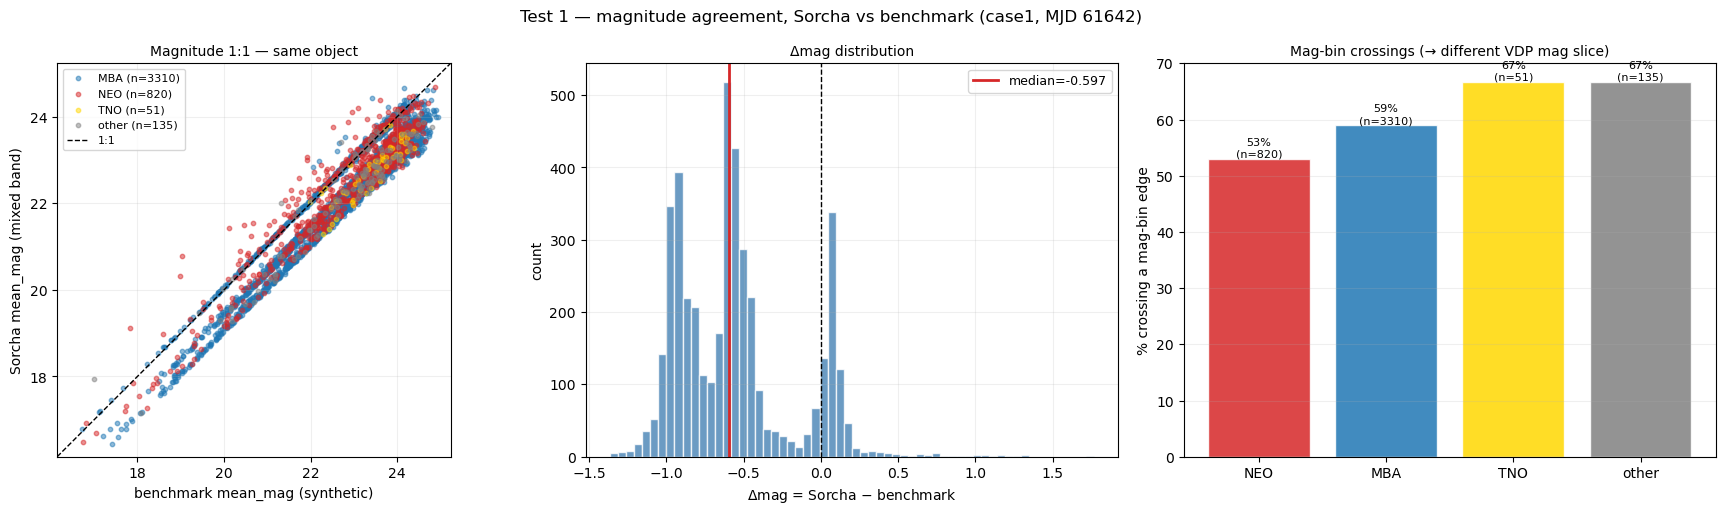

In [12]:
def magbin(m):
    if m < 14: return None
    if m < 16: return '14_16'
    if m < 18: return '16_18'
    if m < 20: return '18_20'
    if m < 21: return 'mag20'
    if m < 22: return 'mag21'
    if m < 23: return 'mag22'
    if m < 24: return 'mag23'
    return 'mag24+'

# benchmark mean_mag is joined in as mean_mag_b
bmag = bench.set_index('s3m_objid')['mean_mag']
j = matched['case1'].copy()
j['mag_b'] = j.ObjID.map(bmag)
j['dmag'] = j.mean_mag - j.mag_b                       # sorcha − benchmark
j['bin_s'] = j.mean_mag.map(magbin)
j['bin_b'] = j.mag_b.map(magbin)
j['bin_cross'] = j.bin_s != j.bin_b

print(f'case1: {len(j)} pairs')
print(f'  Δmag (sorcha−bench):  median={j.dmag.median():+.3f}  mean={j.dmag.mean():+.3f}  '
      f'std={j.dmag.std():.3f}  |Δmag|>0.5: {100*(j.dmag.abs()>0.5).mean():.1f}%')
print(f'  mag-bin crossings:    {j.bin_cross.sum()} / {len(j)} ({100*j.bin_cross.mean():.1f}%)')
print('\n  per population:')
for pop, g in j.groupby('population'):
    print(f'    {pop:6s} n={len(g):4d}  Δmag med={g.dmag.median():+.3f}  '
          f'|Δmag| med={g.dmag.abs().median():.3f}  bin-cross={100*g.bin_cross.mean():.1f}%')

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))

# panel 1: 1:1 scatter
ax = axes[0]
for pop, g in j.groupby('population'):
    ax.scatter(g.mag_b, g.mean_mag, s=10, alpha=0.5, color=POP_COLORS.get(pop,'grey'), label=f'{pop} (n={len(g)})')
lim = [j[['mag_b','mean_mag']].min().min()-0.3, j[['mag_b','mean_mag']].max().max()+0.3]
ax.plot(lim, lim, 'k--', lw=1, label='1:1')
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect('equal')
ax.set_xlabel('benchmark mean_mag (synthetic)'); ax.set_ylabel('Sorcha mean_mag (mixed band)')
ax.legend(fontsize=8); ax.grid(alpha=0.2)
ax.set_title('Magnitude 1:1 — same object', fontsize=10)

# panel 2: Δmag histogram
ax = axes[1]
ax.hist(j.dmag.clip(-2, 2), bins=60, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(0, color='k', lw=1, ls='--')
ax.axvline(j.dmag.median(), color='tab:red', lw=2, label=f'median={j.dmag.median():+.3f}')
ax.set_xlabel(r'$\Delta$mag = Sorcha − benchmark'); ax.set_ylabel('count')
ax.legend(fontsize=9); ax.grid(alpha=0.2)
ax.set_title('Δmag distribution', fontsize=10)

# panel 3: bin-crossing bar per population
ax = axes[2]
pops = [p for p in ['NEO','MBA','TNO','other'] if p in j.population.unique()]
frac = [100*j[j.population==p].bin_cross.mean() for p in pops]
ncnt = [len(j[j.population==p]) for p in pops]
bars = ax.bar(pops, frac, color=[POP_COLORS.get(p,'grey') for p in pops], alpha=0.85, edgecolor='white')
for b, f, nn in zip(bars, frac, ncnt):
    ax.text(b.get_x()+b.get_width()/2, f, f'{f:.0f}%\n(n={nn})', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('% crossing a mag-bin edge')
ax.set_title('Mag-bin crossings (→ different VDP mag slice)', fontsize=10)
ax.grid(alpha=0.2, axis='y')

fig.suptitle(f'Test 1 — magnitude agreement, Sorcha vs benchmark (case1, MJD {NIGHT})', fontsize=12)
plt.tight_layout()
plt.savefig('Figures/nbody_id_test1_magnitude.png', dpi=150, bbox_inches='tight')
plt.show()